# Installing Environments

In [ ]:
!pip -q uninstall -y transformers torch torchvision torchaudio accelerate datasets sentencepiece

In [ ]:
!pip -q install \
torch==2.6.0 \
torchvision==0.21.0 \
torchaudio==2.6.0 \
transformers==4.48.3 \
accelerate==1.3.0 \
datasets==3.2.0 \
sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 121.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.6/336.6 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

# Importing Libraries

In [ ]:
import torch
import transformers
import datasets
import accelerate

print("Torch       :", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets    :", datasets.__version__)
print("Accelerate  :", accelerate.__version__)

Torch       : 2.6.0+cu124
Transformers: 4.48.3
Datasets    : 3.2.0
Accelerate  : 1.3.0


In [ ]:
import numpy as np
import pandas as pd

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Mount Data From Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
TRAIN_PATH = "/content/drive/MyDrive/ABSA_Training_New/train.csv"
VALID_PATH = "/content/drive/MyDrive/ABSA_Training_New/validation.csv"
TEST_PATH  = "/content/drive/MyDrive/ABSA_Training_New/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
valid_df = pd.read_csv(VALID_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)

(6368, 6)
(796, 6)
(797, 6)


In [ ]:
train_df = train_df.dropna(subset=["sentiment"])
valid_df = valid_df.dropna(subset=["sentiment"])
test_df = test_df.dropna(subset=["sentiment"])

# Using Separator

In [ ]:
train_df["text_input"] = (
    train_df["aspect"] + " [SEP] " + train_df["text"]
)

valid_df["text_input"] = (
    valid_df["aspect"] + " [SEP] " + valid_df["text"]
)

test_df["text_input"] = (
    test_df["aspect"] + " [SEP] " + test_df["text"]
)

In [ ]:
train_dataset = Dataset.from_pandas(
    train_df[["text_input", "sentiment_label"]]
)

valid_dataset = Dataset.from_pandas(
    valid_df[["text_input", "sentiment_label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["text_input", "sentiment_label"]]
)

In [ ]:
MODEL_NAME = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
def tokenize(batch):

    return tokenizer(

        batch["text_input"],

        truncation=True,

        max_length=128

    )

In [ ]:
train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

valid_dataset = valid_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/6368 [00:00<?, ? examples/s]

Map:   0%|          | 0/796 [00:00<?, ? examples/s]

Map:   0%|          | 0/797 [00:00<?, ? examples/s]

In [ ]:
train_dataset = train_dataset.rename_column(
    "sentiment_label",
    "labels"
)

valid_dataset = valid_dataset.rename_column(
    "sentiment_label",
    "labels"
)

test_dataset = test_dataset.rename_column(
    "sentiment_label",
    "labels"
)

In [ ]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=1
    )

    precision, recall, f1, _ = precision_recall_fscore_support(

        labels,

        predictions,

        average="weighted"

    )

    acc = accuracy_score(
        labels,
        predictions
    )

    return {

        "accuracy": acc,

        "precision": precision,

        "recall": recall,

        "f1": f1

    }

In [ ]:
from transformers import AutoConfig

MODEL_NAME = "indobenchmark/indobert-base-p1"

config = AutoConfig.from_pretrained(MODEL_NAME)

config.num_labels = 3

config.id2label = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

config.label2id = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config,
    ignore_mismatched_sizes=True
)

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",

    evaluation_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    load_best_model_at_end=True,

    logging_steps=50,

    report_to="none",

    save_total_limit=1,

    seed=42
)

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=valid_dataset,

    tokenizer=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

/tmp/ipykernel_1439/1906930890.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.278600,0.247277,0.923367,0.919195,0.923367,0.920392
2,0.193700,0.252077,0.932161,0.930405,0.932161,0.930964
3,0.116200,0.300921,0.937186,0.934878,0.937186,0.934331
4,0.068200,0.376247,0.933417,0.930684,0.933417,0.930908
5,0.028100,0.372378,0.934673,0.932254,0.934673,0.932576


TrainOutput(global_step=1990, training_loss=0.14020266398113576, metrics={'train_runtime': 708.1895, 'train_samples_per_second': 44.96, 'train_steps_per_second': 2.81, 'total_flos': 1565187721415136.0, 'train_loss': 0.14020266398113576, 'epoch': 5.0})

In [ ]:
result = trainer.predict(test_dataset)

In [ ]:
y_pred = np.argmax(
    result.predictions,
    axis=1
)

y_true = result.label_ids

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    digits=4
))

              precision    recall  f1-score   support

           0     0.9283    0.9618    0.9447       471
           1     0.6000    0.4000    0.4800        30
           2     0.9239    0.9020    0.9128       296

    accuracy                         0.9184       797
   macro avg     0.8174    0.7546    0.7792       797
weighted avg     0.9143    0.9184    0.9154       797



In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[453   1  17]
 [ 13  12   5]
 [ 22   7 267]]


In [ ]:
plot_df = pd.DataFrame(trainer.state.log_history)
plot_df["epoch_round"] = plot_df["epoch"].round().astype(int)
plot_df.columns

Index(['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'eval_loss',
       'eval_accuracy', 'eval_precision', 'eval_recall', 'eval_f1',
       'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second',
       'train_runtime', 'train_samples_per_second', 'train_steps_per_second',
       'total_flos', 'train_loss', 'epoch_round'],
      dtype='object')

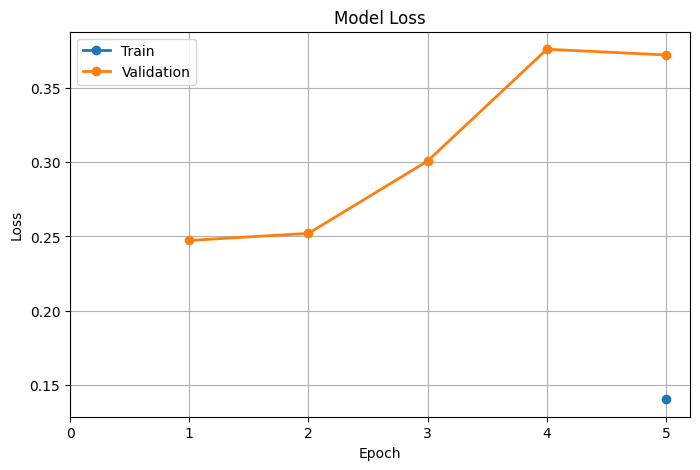

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

# Filter for training loss data (where 'train_loss' is not NaN)
train_log_df = plot_df[plot_df['train_loss'].notna()]

# Filter for evaluation loss data (where 'eval_loss' is not NaN)
eval_log_df = plot_df[plot_df['eval_loss'].notna()]

plt.plot(
    train_log_df["epoch"], # Use float epoch for continuous line
    train_log_df["train_loss"],
    marker="o",
    linestyle="-", # Explicitly set linestyle to solid
    linewidth=2,
    label="Train"
)

plt.plot(
    eval_log_df["epoch"], # Use float epoch for continuous line
    eval_log_df["eval_loss"],
    marker="o",
    linestyle="-", # Explicitly set linestyle to solid
    linewidth=2,
    label="Validation"
)

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Set x-ticks to unique rounded epoch values for clarity
plt.xticks(np.unique(plot_df["epoch_round"]))
plt.grid(True)
plt.legend()

plt.show()

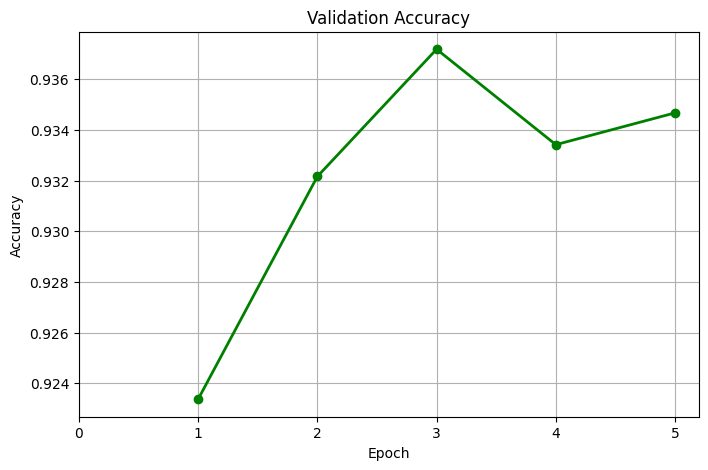

In [ ]:
import numpy as np

plt.figure(figsize=(8,5))

# Filter for evaluation accuracy data (where 'eval_accuracy' is not NaN)
accuracy_log_df = plot_df[plot_df['eval_accuracy'].notna()]

plt.plot(
    accuracy_log_df["epoch"], # Use float epoch for continuous line
    accuracy_log_df["eval_accuracy"],
    marker="o",
    linestyle="-", # Explicitly set linestyle to solid
    linewidth=2,
    color="green"
)

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(np.unique(plot_df["epoch_round"])) # Set x-ticks to unique rounded epoch values for clarity
plt.grid(True)

plt.show()

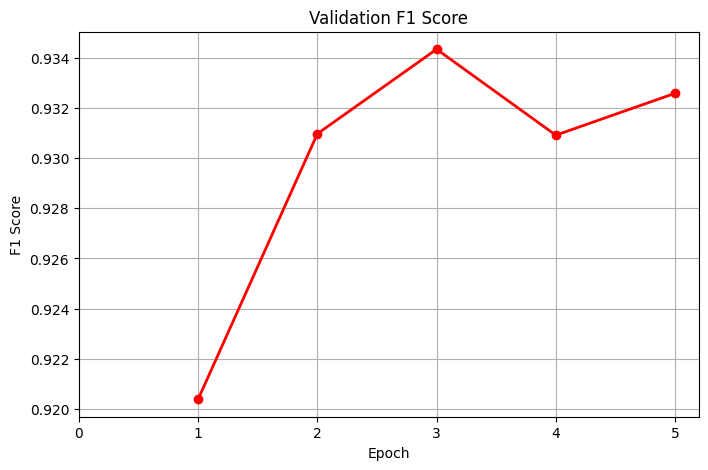

In [ ]:
import numpy as np

plt.figure(figsize=(8,5))

# Filter for evaluation F1 score data (where 'eval_f1' is not NaN)
f1_score_log_df = plot_df[plot_df['eval_f1'].notna()]

plt.plot(
    f1_score_log_df["epoch"], # Use float epoch for continuous line
    f1_score_log_df["eval_f1"],
    marker="o",
    linestyle="-", # Explicitly set linestyle to solid
    linewidth=2,
    color="red"
)

plt.title("Validation F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.xticks(np.unique(plot_df["epoch_round"])) # Set x-ticks to unique rounded epoch values for clarity
plt.grid(True)

plt.show()

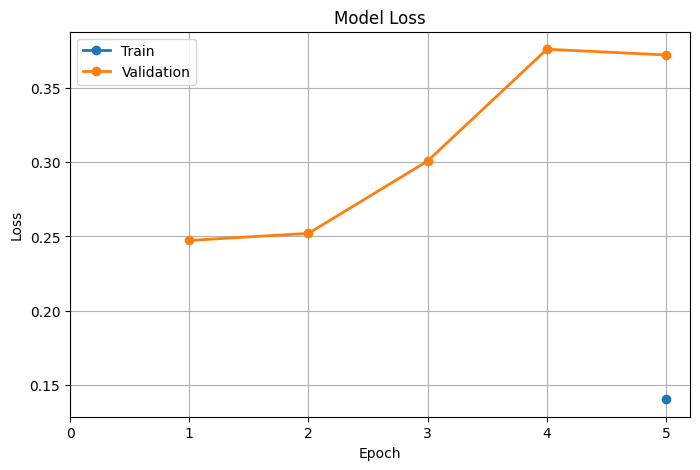

In [ ]:
import numpy as np

plt.figure(figsize=(8,5))

# Filter for training loss data (where 'train_loss' is not NaN)
train_log_df = plot_df[plot_df['train_loss'].notna()]

# Filter for evaluation loss data (where 'eval_loss' is not NaN)
eval_log_df = plot_df[plot_df['eval_loss'].notna()]

plt.plot(
    train_log_df["epoch"], # Use float epoch for continuous line
    train_log_df["train_loss"],
    marker="o",
    linestyle="-", # Explicitly set linestyle to solid
    linewidth=2,
    label="Train"
)

plt.plot(
    eval_log_df["epoch"], # Use float epoch for continuous line
    eval_log_df["eval_loss"],
    marker="o",
    linestyle="-", # Explicitly set linestyle to solid
    linewidth=2,
    label="Validation"
)

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Set x-ticks to unique rounded epoch values for clarity
plt.xticks(np.unique(plot_df["epoch_round"]))
plt.grid(True)
plt.legend()

plt.show()

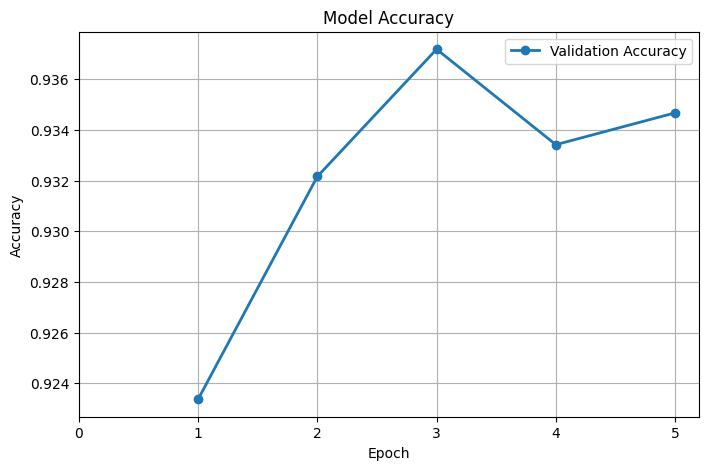

In [ ]:
import numpy as np

plt.figure(figsize=(8,5))

# Filter for evaluation accuracy data (where 'eval_accuracy' is not NaN)
accuracy_log_df = plot_df[plot_df['eval_accuracy'].notna()]

plt.plot(
    accuracy_log_df["epoch"], # Use float epoch for continuous line
    accuracy_log_df["eval_accuracy"],
    marker="o",
    linestyle="-", # Explicitly set linestyle to solid
    linewidth=2,
    label="Validation Accuracy"
)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(np.unique(plot_df["epoch_round"])) # Set x-ticks to unique rounded epoch values for clarity
plt.legend()
plt.grid(True)

plt.show()

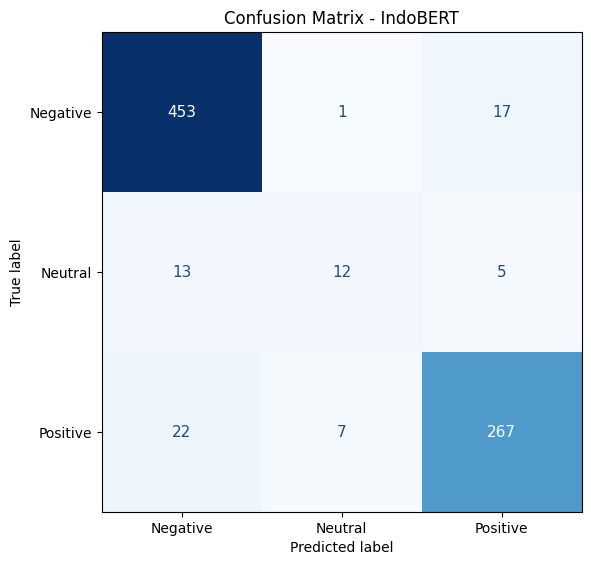

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

labels = ["Negative", "Neutral", "Positive"]

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6,6))

im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix - IndoBERT")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max()/2 else "#1f4e79",
            fontsize=11
        )

plt.tight_layout()
plt.show()

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/ABSA_Training_New/IndoBERT_Best_Model"

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

('/content/drive/MyDrive/ABSA_Training_New/IndoBERT_Best_Model/tokenizer_config.json',
 '/content/drive/MyDrive/ABSA_Training_New/IndoBERT_Best_Model/special_tokens_map.json',
 '/content/drive/MyDrive/ABSA_Training_New/IndoBERT_Best_Model/vocab.txt',
 '/content/drive/MyDrive/ABSA_Training_New/IndoBERT_Best_Model/added_tokens.json',
 '/content/drive/MyDrive/ABSA_Training_New/IndoBERT_Best_Model/tokenizer.json')